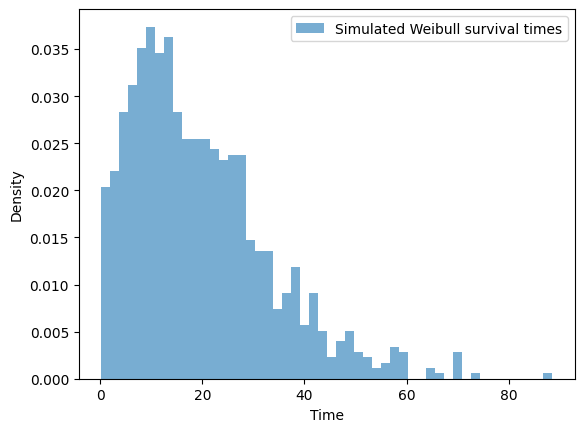

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 参数设定
lam = 0.01   # scale (λ)
gamma = 1.5  # shape (γ)
n = 1000     # 模拟1000个个体

# 生成 U ~ Uniform(0,1)
U = np.random.uniform(0, 1, n)

# 生成事件时间 T
T = (-np.log(U) / lam) ** (1 / gamma)

# 可视化
plt.hist(T, bins=50, density=True, alpha=0.6, label="Simulated Weibull survival times")
plt.xlabel("Time")
plt.ylabel("Density")
plt.legend()
plt.show()


In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 1000  # 模拟1000个个体

# ------------------------
# 生成协变量
# ------------------------
eGFR = np.random.uniform(30, 120, n)  # eGFR 30-120
age = np.random.randint(30, 80, n)    # 年龄 30-80
albuminuria = np.random.choice([0,1,2], size=n)  # 3 stages
diabetes = np.random.choice([0,1,2], size=n)     # 3 stages
hypertension = np.random.choice([0,1], size=n)   # 2 stages

# ------------------------
# Weibull 基线参数
# ------------------------
lam = 0.001  # scale
gamma = 1.5  # shape

# 协变量系数示意（可调整）
beta_eGFR = -0.03       # eGFR 高风险低
beta_age = 0.02         # 年龄大风险高
beta_alb = 0.4          # albuminuria
beta_diab = 0.3         # diabetes
beta_hyper = 0.25       # hypertension

# ------------------------
# 线性风险
# ------------------------
linear_risk = (beta_eGFR*eGFR + beta_age*age +
               beta_alb*albuminuria + beta_diab*diabetes + beta_hyper*hypertension)

# ------------------------
# 生成 AKD 事件时间
# ------------------------
U = np.random.uniform(0,1,n)
time_to_AKD = (-np.log(U) / (lam * np.exp(linear_risk)))**(1/gamma)

# ------------------------
# 构建 DataFrame
# ------------------------
df = pd.DataFrame({
    'eGFR': eGFR,
    'age': age,
    'albuminuria': albuminuria,
    'diabetes': diabetes,
    'hypertension': hypertension,
    'time_to_AKD': time_to_AKD
})

df.head()


,eGFR,age,albuminuria,diabetes,hypertension,time_to_AKD
0,63.708611,76,1,0,0,248.667730
1,115.564288,41,1,0,1,150.088587
2,95.879455,45,0,2,0,156.597900
3,83.879264,53,0,2,1,75.421858
4,44.041678,48,0,2,1,22.719983


In [1]:
# Read the first few lines of the emergency.csv file
import pandas as pd


# Try reading with different encodings to handle the Unicode error
emergency_df = pd.read_csv('../data/emergency.csv', encoding='windows-1252')



# Save the first 100 lines to emergency_sample.csv
emergency_sample = emergency_df.head(100)
emergency_sample.to_csv('../data/emergency_sample.csv', index=False)

emergency_df.head()

/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_36899/4280611241.py:6: DtypeWarning: Columns (8,132,133,134) have mixed types. Specify dtype option on import or set low_memory=False.
  emergency_df = pd.read_csv('../data/emergency.csv', encoding='windows-1252')


,Unnamed: 0,AE_CASE_NUMBER,#PATIENT_CODE,AGE,DEATH_DATE,DEATH_REASON,GENDER,NATIONALITY,POSTAL_CODE,RACE,...,DIAGNOSIS_CODE_Primary_2,DIAGNOSIS_DESCRIPTION_Primary_1,DIAGNOSIS_DESCRIPTION_Primary_2,DIAGNOSIS_CODE_Secondary_1,DIAGNOSIS_CODE_Secondary_2,DIAGNOSIS_CODE_Secondary_3,DIAGNOSIS_DESCRIPTION_Secondary_1,DIAGNOSIS_DESCRIPTION_Secondary_2,DIAGNOSIS_DESCRIPTION_Secondary_3,year
0,1,00000C60C4122D134829896AF2EE33A7,A62401314B262C6576B454AC6A28235E,30.0,NaN,NaN,MALE,Singapore Citizen,4600.0,Chinese,...,NaN,Cellulitis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018
1,2,00000CCC36795BC7D604069B032DE81D,B6D4474C33CCFBE88B1E6AFA14AB1CBD,53.0,NaN,NaN,FEMALE,Singapore Citizen,5702.0,Chinese,...,NaN,Acute Loss of Short Term Memory,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008
2,3,00000F784DDDDB38D43C26018702EA4A,8613CC9F0A3523FF969E3C15DBF147F2,66.0,NaN,NaN,FEMALE,Singapore Citizen,3300.0,Chinese,...,NaN,Cellulitis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014
3,4,0000156D5B4BC06B11C4983753A2C187,B6EB1F8034184B9D7FB6FB180BCE6D38,51.0,NaN,NaN,MALE,Singapore Citizen,6803.0,Chinese,...,NaN,Viral fever,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020
4,5,00001B3D4DD023D6566EC69B148F4666,7F532DD03EC1865BB51D83855EBE57C4,24.0,NaN,NaN,FEMALE,Thai,1896.0,Thai,...,NaN,musculoskeletal pain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009


In [2]:
emergency_df.shape

(1833908, 139)

## analysis on ckd admission

In [8]:
# 计算表达式的每一项并分别输出
term1 = (51750 - 1) * (6.82 ** 2)
term2 = (6646 - 1) * (8.15 ** 2)
term3 = (5887 - 1) * (9.21 ** 2)
term4 = (501 - 1) * (9.40 ** 2)
print("第一项 (51750-1) * (6.822^2):", term1)
print("第二项 (6646-1) * (8.152^2):", term2)
print("第三项 (5887-1) * (9.212^2):", term3)
print("第四项 (501-1) * (9.402^2):", term4)
result = term1 + term2 + term3 + term4
print("总和为:", result)


第一项 (51750-1) * (6.822^2): 2406970.1876000003
第二项 (6646-1) * (8.152^2): 441377.5125
第三项 (5887-1) * (9.212^2): 499274.6526000001
第四项 (501-1) * (9.402^2): 44180.00000000001
总和为: 3391802.3527000006


In [11]:
diagnosis_cols

['DIAGNOSIS_CODE_Primary_1',
 'DIAGNOSIS_CODE_Primary_2',
 'DIAGNOSIS_DESCRIPTION_Primary_1',
 'DIAGNOSIS_DESCRIPTION_Primary_2',
 'DIAGNOSIS_CODE_Secondary_1',
 'DIAGNOSIS_CODE_Secondary_2',
 'DIAGNOSIS_CODE_Secondary_3',
 'DIAGNOSIS_DESCRIPTION_Secondary_1',
 'DIAGNOSIS_DESCRIPTION_Secondary_2',
 'DIAGNOSIS_DESCRIPTION_Secondary_3']


Column: DIAGNOSIS_DESCRIPTION_Primary_1
year
2008    2755
2009    3147
2010    3261
2011    2663
2012    2681
2013    2495
2014    2601
2015    2651
2016    2377
2017    2293
2018    2198
2019    2190
2020    1781
Name: count, dtype: int64

Column: DIAGNOSIS_DESCRIPTION_Primary_2
year
2015    17
2016    89
2017    69
2018    68
2019    64
2020    33
Name: count, dtype: int64

Column: DIAGNOSIS_DESCRIPTION_Secondary_1
year
2008    1779
2009    2065
2010    1625
2011    1764
2012    1401
2013    1390
2014    1309
2015    1105
2016    1305
2017    1240
2018    1156
2019    1004
2020     967
Name: count, dtype: int64

Column: DIAGNOSIS_DESCRIPTION_Secondary_2
year
2008    611
2009    466
2010    484
2011    498
2012    322
2013    292
2014    295
2015    261
2016    315
2017    304
2018    236
2019    183
2020    258
Name: count, dtype: int64

Column: DIAGNOSIS_DESCRIPTION_Secondary_3
year
2008    270
2009    152
2010    221
2011    160
2012    165
2013     63
2014     64
2015     49
2016

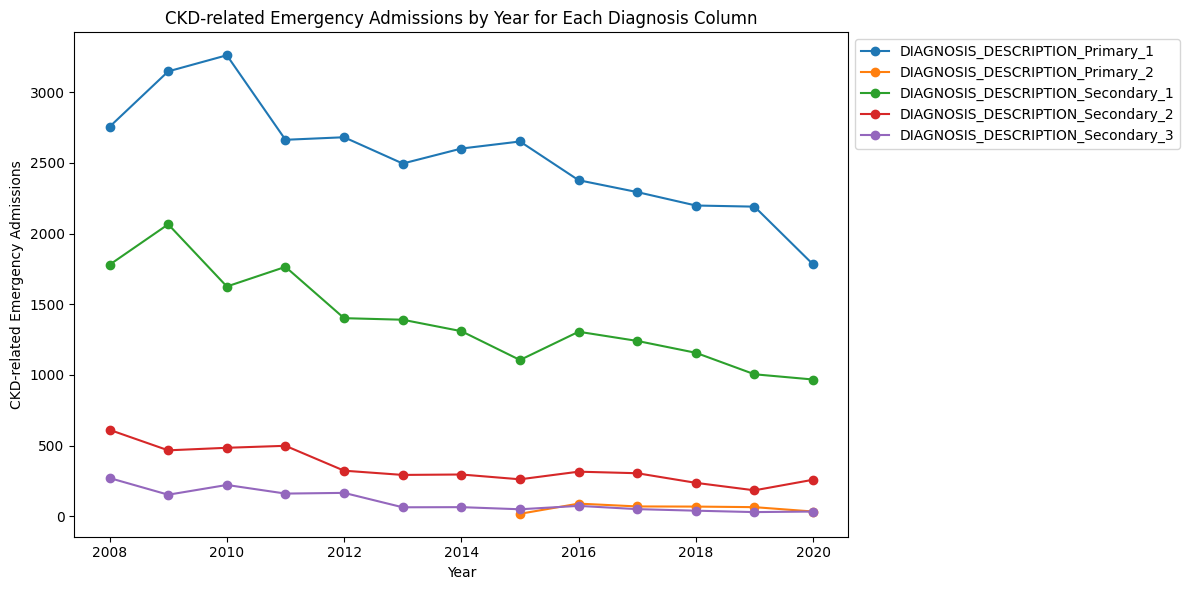

In [13]:
# 先筛选所有诊断列中包含'Chronic kidney'或'Chronic renal'的行，认为这些为CKD相关急诊
ckd_mask = pd.Series([False] * len(emergency_df))
diagnosis_cols = [col for col in emergency_df.columns if 'DIAGNOSIS' in col.upper()]
diagnosis_cols = [col for col in diagnosis_cols if 'code' not in col.lower()]

# 针对每个诊断列，分别统计每年包含'kidney'或'renal'的入院数，并输出
ckd_counts_by_col_year = {}

for col in diagnosis_cols:
    if emergency_df[col].dtype == 'object':
        # 针对该列，筛选包含'kidney'或'renal'的行
        mask_kidney = emergency_df[col].str.contains('kidney', case=False, na=False)
        mask_renal = emergency_df[col].str.contains('renal', case=False, na=False)
        mask = mask_kidney | mask_renal
        filtered = emergency_df[mask]
        # 按年份统计
        year_counts = filtered['year'].value_counts().sort_index()
        ckd_counts_by_col_year[col] = year_counts
        print(f"\nColumn: {col}")
        print(year_counts)

# 如果需要合并所有诊断列的结果（即只要任一诊断列包含'kidney'或'renal'就计入），可如下操作：
overall_ckd_mask = pd.Series([False] * len(emergency_df))
for col in diagnosis_cols:
    if emergency_df[col].dtype == 'object':
        overall_ckd_mask = overall_ckd_mask | emergency_df[col].str.contains('kidney', case=False, na=False)
        overall_ckd_mask = overall_ckd_mask | emergency_df[col].str.contains('renal', case=False, na=False)
overall_ckd_emergency_df = emergency_df[overall_ckd_mask]
overall_ckd_year_counts = overall_ckd_emergency_df['year'].value_counts().sort_index()
print("\nOverall CKD-related emergency admissions by year (any column):")
print(overall_ckd_year_counts)

import matplotlib.pyplot as plt

# 可视化：每个诊断列每年CKD相关急诊入院数的折线图
plt.figure(figsize=(12, 6))
for col in ckd_counts_by_col_year:
    # 只画有数据的列
    year_counts = ckd_counts_by_col_year[col]
    plt.plot(year_counts.index, year_counts.values, marker='o', label=col)

plt.xlabel('Year')
plt.ylabel('CKD-related Emergency Admissions')
plt.title('CKD-related Emergency Admissions by Year for Each Diagnosis Column')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


In [14]:
ckd_emergency_df

,Unnamed: 0,AE_CASE_NUMBER,#PATIENT_CODE,AGE,DEATH_DATE,DEATH_REASON,GENDER,NATIONALITY,POSTAL_CODE,RACE,...,DIAGNOSIS_CODE_Primary_2,DIAGNOSIS_DESCRIPTION_Primary_1,DIAGNOSIS_DESCRIPTION_Primary_2,DIAGNOSIS_CODE_Secondary_1,DIAGNOSIS_CODE_Secondary_2,DIAGNOSIS_CODE_Secondary_3,DIAGNOSIS_DESCRIPTION_Secondary_1,DIAGNOSIS_DESCRIPTION_Secondary_2,DIAGNOSIS_DESCRIPTION_Secondary_3,year
62,63,0002CEA64334CD1D106DD1C9DBC64500,FB30E403487139857A41A03E13BC8275,88.0,2016-12-27,NaN,MALE,Singapore Citizen,3100.0,Chinese,...,NaN,Fluid Overload for investigation,NaN,7994,2768,585.0,Cachexia,Hypokalaemia,Chronic Renal Failure,2011
446,447,000ED4F64018A6F61003B1DF77DC299E,8B2ED28A6927D8AB7C66985694F85A0A,53.0,2017-09-22,NaN,MALE,Singapore Citizen,5304.0,Indian,...,NaN,Fluid Overload Disorder,NaN,585,NaN,NaN,Chronic Renal Failure,NaN,NaN,2008
615,616,00151D596741CA3B731669BFDAFF3BA4,64DE4092633DFA13226A82AAAD097031,87.0,2016-01-25,NaN,MALE,Singapore Citizen,4600.0,Chinese,...,NaN,Fluid Overload Disorder,NaN,585,NaN,NaN,Chronic Renal Failure,NaN,NaN,2014
709,710,0018789E01936B1EDEEB905AA5842BBC,0F5758F4315F5048647B3D47C68195C1,81.0,2018-09-18,NaN,FEMALE,Singapore Citizen,5568.0,Chinese,...,NaN,CKD - chronic kidney disease,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018
737,738,001A08672718BCFC39709C91A200FAD6,4AB9A3AFF094D7865F951DFF63F019D3,59.0,2017-07-30,NaN,MALE,Singapore Citizen,4400.0,Other Races,...,NaN,Cerebrovascular Accident,NaN,2761,4019,585.0,Hyponatraemia,Hypertension,Chronic Renal Failure,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1832920,1832921,FFDC798CA2147FFACDA53DF6F9A5AF75,4E4A524E7BB3CE82BCDFB73F93E7434A,78.0,2017-08-04,NaN,FEMALE,Singapore Citizen,5448,Chinese,...,NaN,Chronic Renal Failure,NaN,250.0,NaN,NaN,Diabetes Mellitus,NaN,NaN,2008
1833142,1833143,FFE529CE451443E7F105C1C662572562,876EBCA5810311EC75828EC285950768,51.0,NaN,NaN,MALE,Singapore Citizen,5501,Chinese,...,NaN,Acute-on-Chronic Renal Failure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009
1833296,1833297,FFEAF65BA23AFBB3C56B13AF529D0937,42BAA5D11B7C2983C391126C8138C1FA,62.0,NaN,NaN,MALE,Singapore Citizen,6504,Chinese,...,NaN,Acute-on-chronic renal failure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020
1833577,1833578,FFF5BF57AF9DB0596C60DDB4946E16CC,AF9F8F8F9A8CD24D60249A5FF969EE23,72.0,2017-06-17,NaN,MALE,Singapore Citizen,1601,Chinese,...,NaN,Fall risk,NaN,2872015018.0,NaN,NaN,CKD - chronic kidney disease,NaN,NaN,2017


Series([], Name: count, dtype: int64)

Found 466 entries with 'kidney' in DIAGNOSIS_DESCRIPTION_Primary_1:
DIAGNOSIS_DESCRIPTION_Primary_1
CKD - chronic kidney disease                                                       216
Chronic kidney disease                                                             160
CKD - Chronic kidney disease                                                        33
Chronic kidney disease stage 5                                                      21
Chronic Kidney Disease                                                               4
Chronic kidney disease due to hypertension                                           2
Acute on chronic kidney disease                                                      2
Fluid overload secondary to chronic kidney disease                                   2
acute on chronic kidney disease                                                      2
Acute on Chronic Kidney Disease                                               

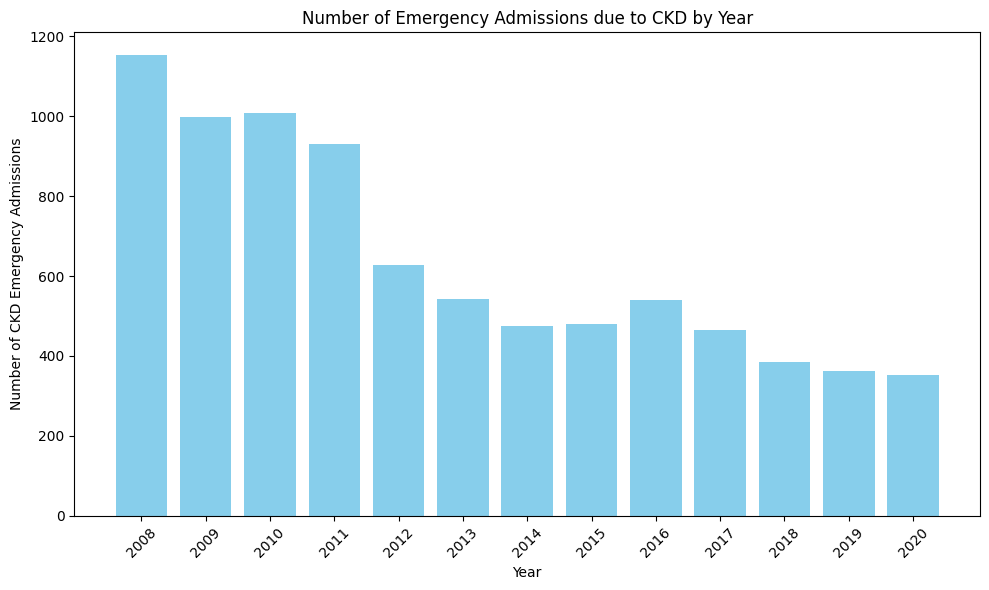

/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_36899/257255837.py:56: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  acute_ckd_df = ckd_emergency_df[acute_ckd_mask]
/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_36899/257255837.py:57: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  non_acute_ckd_df = ckd_emergency_df[~acute_ckd_mask]


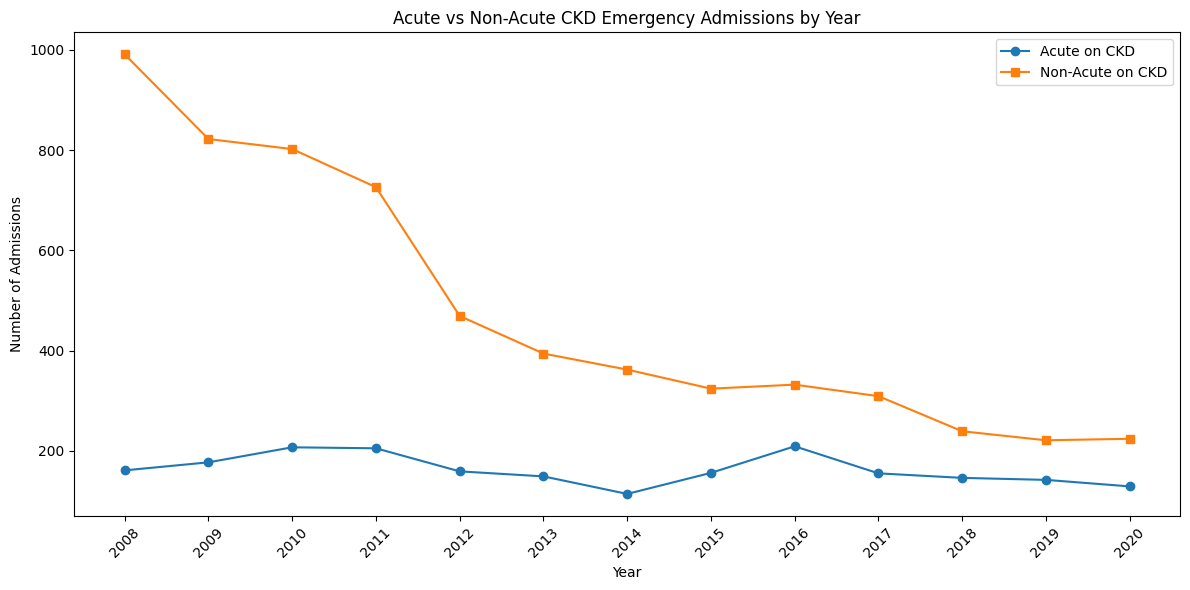

In [15]:
# Get diagnosis columns and year column
diagnosis_cols = [col for col in emergency_df.columns if 'DIAGNOSIS' in col.upper()]
diagnosis_cols.append('year')  # Add year column
diagnosis_df = emergency_df[diagnosis_cols]


for col in diagnosis_cols:
        if emergency_df[col].dtype == 'object':
            kidney_entries = emergency_df[emergency_df[col].str.contains('Chronic kidney', case=False, na=False)]
            renal_entries = emergency_df[emergency_df[col].str.contains('Chronic renal', case=False, na=False)]
            if len(kidney_entries) > 0:
                print(f"\nFound {len(kidney_entries)} entries with 'kidney' in {col}:")
                print(kidney_entries[col].value_counts())
            if len(renal_entries) > 0:
                print(f"\nFound {len(renal_entries)} entries with 'renal' in {col}:")
                print(renal_entries[col].value_counts())
            # combine kidney_entries and renal_entries
            combined_entries = pd.concat([kidney_entries, renal_entries])
            print(combined_entries[col].value_counts())


import matplotlib.pyplot as plt

# 1. 统计每年因CKD急诊入院的数量，并可视化

# 先筛选所有诊断列中包含'Chronic kidney'或'Chronic renal'的行，认为这些为CKD相关急诊
ckd_mask = pd.Series([False] * len(emergency_df))
diagnosis_cols = [col for col in emergency_df.columns if 'DIAGNOSIS' in col.upper()]
for col in diagnosis_cols:
    if emergency_df[col].dtype == 'object':
        ckd_mask = ckd_mask | emergency_df[col].str.contains('Chronic kidney', case=False, na=False)
        ckd_mask = ckd_mask | emergency_df[col].str.contains('Chronic renal', case=False, na=False)

ckd_emergency_df = emergency_df[ckd_mask]

# 按年份统计CKD急诊入院数
ckd_year_counts = ckd_emergency_df['year'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.bar(ckd_year_counts.index.astype(str), ckd_year_counts.values, color='skyblue')
plt.xlabel('Year')
plt.ylabel('Number of CKD Emergency Admissions')
plt.title('Number of Emergency Admissions due to CKD by Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. 在CKD相关急诊中，进一步区分是否为急性（acute）相关

# acute on CKD: CKD诊断列中同时包含'acute'关键字
acute_ckd_mask = pd.Series([False] * len(ckd_emergency_df))
for col in diagnosis_cols:
    if ckd_emergency_df[col].dtype == 'object':
        acute_ckd_mask = acute_ckd_mask | ckd_emergency_df[col].str.contains('acute', case=False, na=False)

acute_ckd_df = ckd_emergency_df[acute_ckd_mask]
non_acute_ckd_df = ckd_emergency_df[~acute_ckd_mask]

# 按年份统计
acute_ckd_year_counts = acute_ckd_df['year'].value_counts().sort_index()
non_acute_ckd_year_counts = non_acute_ckd_df['year'].value_counts().sort_index()

# 画图
plt.figure(figsize=(12,6))
plt.plot(acute_ckd_year_counts.index.astype(str), acute_ckd_year_counts.values, marker='o', label='Acute on CKD')
plt.plot(non_acute_ckd_year_counts.index.astype(str), non_acute_ckd_year_counts.values, marker='s', label='Non-Acute on CKD')
plt.xlabel('Year')
plt.ylabel('Number of Admissions')
plt.title('Acute vs Non-Acute CKD Emergency Admissions by Year')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# 对 acute_ckd_df 和 non_acute_ckd_df 分别按年份统计各诊断列中 'renal' 或 'kidney' 关键字出现次数（不重复计数同一行）

def count_renal_kidney_by_year(df, desc_cols):
    yearly_counts = {}
    for year, group in df.groupby('year'):
        counted_mask = pd.Series([False] * len(group), index=group.index)
        col_counts = {}
        for col in desc_cols:
            not_counted = ~counted_mask
            match_mask = group.loc[not_counted, col].astype(str).str.contains('renal|kidney', case=False, na=False)
            count = match_mask.sum()
            col_counts[col] = count
            counted_mask.loc[not_counted[not_counted].index[match_mask]] = True
        yearly_counts[year] = col_counts
    return pd.DataFrame.from_dict(yearly_counts, orient='index').sort_index()

desc_cols = [
    'DIAGNOSIS_DESCRIPTION_Primary_1',
    'DIAGNOSIS_DESCRIPTION_Primary_2',
    'DIAGNOSIS_DESCRIPTION_Secondary_1',
    'DIAGNOSIS_DESCRIPTION_Secondary_2',
    'DIAGNOSIS_DESCRIPTION_Secondary_3'
]

# 统计 acute_ckd_df
acute_renal_kidney_counts = count_renal_kidney_by_year(acute_ckd_df, desc_cols)
print("Acute CKD renal/kidney keyword counts by year and column:")
print(acute_renal_kidney_counts)

# 统计 non_acute_ckd_df
non_acute_renal_kidney_counts = count_renal_kidney_by_year(non_acute_ckd_df, desc_cols)
print("Non-Acute CKD renal/kidney keyword counts by year and column:")
print(non_acute_renal_kidney_counts)




Acute CKD renal/kidney keyword counts by year and column:
      DIAGNOSIS_DESCRIPTION_Primary_1  DIAGNOSIS_DESCRIPTION_Primary_2  \
2008                              101                                0   
2009                               90                                0   
2010                              110                                0   
2011                               77                                0   
2012                               76                                0   
2013                               69                                0   
2014                               49                                0   
2015                               73                                2   
2016                               92                                9   
2017                               65                                4   
2018                               73                                0   
2019                               76                 


Validating Acute CKD counts:
Year 2008: original rows = 161, sum of keyword counts = 161
Year 2009: original rows = 177, sum of keyword counts = 177
Year 2010: original rows = 207, sum of keyword counts = 207
Year 2011: original rows = 205, sum of keyword counts = 205
Year 2012: original rows = 159, sum of keyword counts = 159
Year 2013: original rows = 149, sum of keyword counts = 149
Year 2014: original rows = 114, sum of keyword counts = 114
Year 2015: original rows = 156, sum of keyword counts = 156
Year 2016: original rows = 209, sum of keyword counts = 209
Year 2017: original rows = 155, sum of keyword counts = 155
Year 2018: original rows = 146, sum of keyword counts = 146
Year 2019: original rows = 142, sum of keyword counts = 142
Year 2020: original rows = 129, sum of keyword counts = 129
All years validated: sum of keyword counts matches original row counts for Acute CKD.

Validating Non-Acute CKD counts:
Year 2008: original rows = 991, sum of keyword counts = 991
Year 2009:

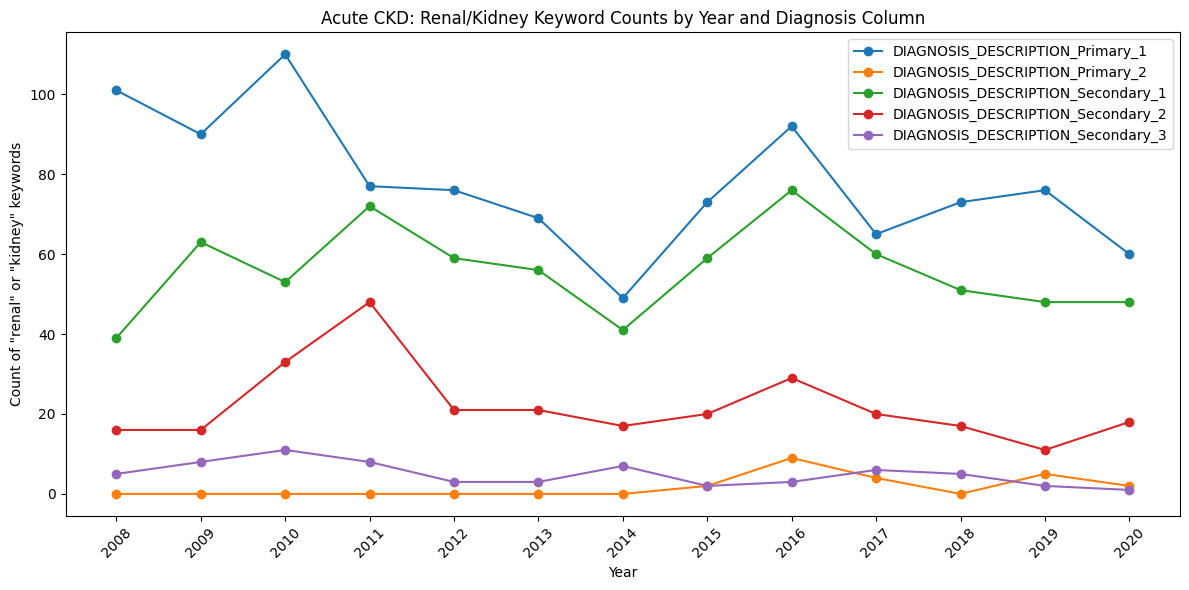

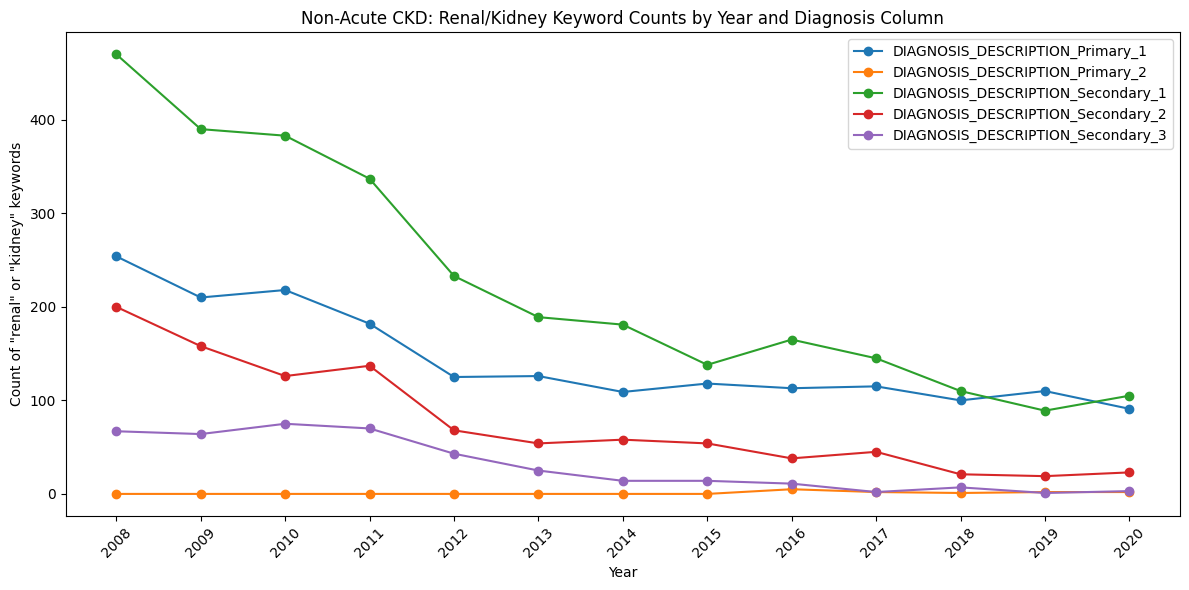

In [18]:

# 验证统计结果：每年各列计数之和应等于原数据中该年的行数
def validate_counts(df, counts_df, label):
    # df: 原始数据（acute_ckd_df 或 non_acute_ckd_df）
    # counts_df: 统计出的每年各列计数
    # label: 字符串标签
    print(f"\nValidating {label} counts:")
    years = sorted(df['year'].unique())
    all_valid = True
    for year in years:
        original_count = (df['year'] == year).sum()
        counted_sum = counts_df.loc[year].sum()
        print(f"Year {year}: original rows = {original_count}, sum of keyword counts = {counted_sum}")
        if counted_sum != original_count:
            print(f"  [WARNING] Mismatch in year {year}!")
            all_valid = False
    if all_valid:
        print(f"All years validated: sum of keyword counts matches original row counts for {label}.")
    else:
        print(f"Some years have mismatches for {label}.")

validate_counts(acute_ckd_df, acute_renal_kidney_counts, "Acute CKD")
validate_counts(non_acute_ckd_df, non_acute_renal_kidney_counts, "Non-Acute CKD")

# 可视化每年各诊断列中 'renal' 或 'kidney' 关键字出现次数
import matplotlib.pyplot as plt

def plot_renal_kidney_counts(counts_df, title):
    plt.figure(figsize=(12, 6))
    for col in counts_df.columns:
        plt.plot(counts_df.index.astype(str), counts_df[col], marker='o', label=col)
    plt.xlabel('Year')
    plt.ylabel('Count of "renal" or "kidney" keywords')
    plt.title(title)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_renal_kidney_counts(acute_renal_kidney_counts, 'Acute CKD: Renal/Kidney Keyword Counts by Year and Diagnosis Column')
plot_renal_kidney_counts(non_acute_renal_kidney_counts, 'Non-Acute CKD: Renal/Kidney Keyword Counts by Year and Diagnosis Column')


# analysis on akd 

In [ ]:
# Get diagnosis columns and year column
diagnosis_cols = [col for col in emergency_df.columns if 'DIAGNOSIS' in col.upper()]
diagnosis_cols.append('year')  # Add year column
diagnosis_df = emergency_df[diagnosis_cols]


for col in diagnosis_cols:
        if emergency_df[col].dtype == 'object':
            kidney_entries = emergency_df[emergency_df[col].str.contains('Acute kidney', case=False, na=False)]
            renal_entries = emergency_df[emergency_df[col].str.contains('Acute renal', case=False, na=False)]
            if len(kidney_entries) > 0:
                print(f"\nFound {len(kidney_entries)} entries with 'kidney' in {col}:")
                print(kidney_entries[col].value_counts())
            if len(renal_entries) > 0:
                print(f"\nFound {len(renal_entries)} entries with 'renal' in {col}:")
                print(renal_entries[col].value_counts())
            # combine kidney_entries and renal_entries
            combined_entries = pd.concat([kidney_entries, renal_entries])
            print(combined_entries[col].value_counts())

 


Series([], Name: count, dtype: int64)

Found 1514 entries with 'kidney' in DIAGNOSIS_DESCRIPTION_Primary_1:
DIAGNOSIS_DESCRIPTION_Primary_1
AKI - Acute kidney injury                                                        1367
Acute Kidney Injury                                                                28
Acute kidney injury                                                                17
acute kidney injury                                                                 6
Gastroenteritis with acute kidney injury                                            3
                                                                                 ... 
Acute Kidney Injury with HAGMA                                                      1
Acute Kidney Injury with functional decline                                         1
Acute Kidney Injury on Top of Acute Pyelonephritis; Calculus Of Kidney, Right       1
Gastroenteritis cx by acute kidney injury and hypotension                           1


In [20]:

# Create a dataframe with only diagnosis columns and filter for 'Acute kidney' or 'Acute renal'
diagnosis_cols = [col for col in emergency_df.columns if 'DIAGNOSIS' in col.upper()]
diagnosis_cols.append('year')  # Add year column
# Create boolean mask to find rows containing 'Acute kidney' or 'Acute renal' in any diagnosis column
mask = pd.Series([False] * len(emergency_df))

for col in diagnosis_cols:
    if emergency_df[col].dtype == 'object':
        # Check for 'Acute kidney' OR 'Acute renal' in this column
        acute_kidney_mask = emergency_df[col].str.contains('Acute kidney', case=False, na=False)
        acute_renal_mask = emergency_df[col].str.contains('Acute renal', case=False, na=False)
        mask = mask | acute_kidney_mask | acute_renal_mask

# Filter the dataframe to only include rows with acute kidney/renal conditions
acute_kidney_renal_df = emergency_df[mask][diagnosis_cols]

print(f"Found {len(acute_kidney_renal_df)} rows containing 'Acute kidney' or 'Acute renal'")
print(f"Dataframe shape: {acute_kidney_renal_df.shape}")
print("\nFirst few rows:")
print(acute_kidney_renal_df.head())

# Show value counts of all diagnosis entries in the filtered dataset
print("\nDiagnosis value counts in filtered dataset:")
for col in diagnosis_cols:
    if acute_kidney_renal_df[col].dtype == 'object':
        non_null_values = acute_kidney_renal_df[col].dropna()
        if len(non_null_values) > 0:
            print(f"\n{col}:")
            print(non_null_values.value_counts())


Found 7014 rows containing 'Acute kidney' or 'Acute renal'
Dataframe shape: (7014, 11)

First few rows:
    DIAGNOSIS_CODE_Primary_1  DIAGNOSIS_CODE_Primary_2  \
32                2156536016                       NaN   
414                372826011                       NaN   
431                      486                       NaN   
774                      458                       NaN   
793               4006475100                       NaN   

    DIAGNOSIS_DESCRIPTION_Primary_1 DIAGNOSIS_DESCRIPTION_Primary_2  \
32                        Giddiness                             NaN   
414                 Weakness of leg                             NaN   
431                       Pneumonia                             NaN   
774                     Hypotension                             NaN   
793       AKI - Acute kidney injury                             NaN   

    DIAGNOSIS_CODE_Secondary_1 DIAGNOSIS_CODE_Secondary_2  \
32                     9001019                 1042100013  

In [21]:
acute_kidney_renal_df

,DIAGNOSIS_CODE_Primary_1,DIAGNOSIS_CODE_Primary_2,DIAGNOSIS_DESCRIPTION_Primary_1,DIAGNOSIS_DESCRIPTION_Primary_2,DIAGNOSIS_CODE_Secondary_1,DIAGNOSIS_CODE_Secondary_2,DIAGNOSIS_CODE_Secondary_3,DIAGNOSIS_DESCRIPTION_Secondary_1,DIAGNOSIS_DESCRIPTION_Secondary_2,DIAGNOSIS_DESCRIPTION_Secondary_3,year
32,2156536016,NaN,Giddiness,NaN,9001019,1042100013,2549970010.0,Pyuria,Acute kidney injury,Traumatic injury,2018
414,372826011,NaN,Weakness of leg,NaN,1230678016,354408015,NaN,Parkinson disease,Acute renal impairment,NaN,2017
431,486,NaN,Pneumonia,NaN,458,584,410.0,Hypotension,Acute Renal Failure,Type 2 MI,2015
774,458,NaN,Hypotension,NaN,584,NaN,NaN,Acute Renal Failure,NaN,NaN,2013
793,4006475100,NaN,AKI - Acute kidney injury,NaN,56807016,NaN,NaN,Viral illness,NaN,NaN,2016
...,...,...,...,...,...,...,...,...,...,...,...
1832766,41990019,NaN,Headache,NaN,4006475100.0,60380017.0,NaN,AKI - Acute kidney injury,Polyarthropathy,NaN,2020
1832925,584,NaN,Acute Renal Failure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008
1832968,7882,NaN,Acute Retention Of Urine,NaN,584.0,NaN,NaN,Acute Renal Failure,NaN,NaN,2012
1833257,42550011,NaN,Gastroenteritis,NaN,4006475100.0,NaN,NaN,AKI - Acute kidney injury,NaN,NaN,2016


In [25]:
# Group by year and calculate frequency of 'renal' and 'kidney' appearances
yearly_counts = []

for year in sorted(acute_kidney_renal_df['year'].unique()):
    year_data = acute_kidney_renal_df[acute_kidney_renal_df['year'] == year]
    
    renal_count = 0
    kidney_count = 0
    
    # Count occurrences of 'renal' and 'kidney' in all diagnosis columns for this year
    for col in diagnosis_cols:
        if year_data[col].dtype == 'object':
            # Count 'renal' appearances (case insensitive)
            renal_mask = year_data[col].str.contains('renal', case=False, na=False)
            renal_count += renal_mask.sum()
            
            # Count 'kidney' appearances (case insensitive)
            kidney_mask = year_data[col].str.contains('kidney', case=False, na=False)
            kidney_count += kidney_mask.sum()
    
    yearly_counts.append({
        'year': year,
        'renal_frequency': renal_count,
        'kidney_frequency': kidney_count,
        'total_cases': len(year_data)
    })

# Convert to DataFrame for better display
yearly_frequency_df = pd.DataFrame(yearly_counts)
print("Yearly frequency of 'renal' and 'kidney' appearances:")
print(yearly_frequency_df)

Yearly frequency of 'renal' and 'kidney' appearances:
    year  renal_frequency  kidney_frequency  total_cases
0   2008              284                 7          277
1   2009              272                 1          262
2   2010              383                 8          370
3   2011              353                 7          345
4   2012              343                30          360
5   2013              359                65          403
6   2014              368                92          442
7   2015              301               191          478
8   2016              196               729          887
9   2017              178               690          845
10  2018               83               762          816
11  2019               79               714          769
12  2020               60               721          760


In [27]:
acute_kidney_renal_df.columns

Index(['DIAGNOSIS_CODE_Primary_1', 'DIAGNOSIS_CODE_Primary_2',
       'DIAGNOSIS_DESCRIPTION_Primary_1', 'DIAGNOSIS_DESCRIPTION_Primary_2',
       'DIAGNOSIS_CODE_Secondary_1', 'DIAGNOSIS_CODE_Secondary_2',
       'DIAGNOSIS_CODE_Secondary_3', 'DIAGNOSIS_DESCRIPTION_Secondary_1',
       'DIAGNOSIS_DESCRIPTION_Secondary_2',
       'DIAGNOSIS_DESCRIPTION_Secondary_3', 'year'],
      dtype='object')

In [31]:
# Count 'renal' or 'kidney' appearances in specific columns by year
yearly_specific_counts = []

for year in sorted(acute_kidney_renal_df['year'].unique()):
    year_data = acute_kidney_renal_df[acute_kidney_renal_df['year'] == year]
    
    # Count in DIAGNOSIS_DESCRIPTION_Primary_1
    primary_desc_1_count = 0
    if 'DIAGNOSIS_DESCRIPTION_Primary_1' in year_data.columns:
        primary_desc_1_mask = year_data['DIAGNOSIS_DESCRIPTION_Primary_1'].str.contains('renal|kidney', case=False, na=False)
        primary_desc_1_count = primary_desc_1_mask.sum()
    
    # Count in DIAGNOSIS_DESCRIPTION_Primary_2
    primary_desc_2_count = 0
    if 'DIAGNOSIS_DESCRIPTION_Primary_2' in year_data.columns:
        primary_desc_2_mask = year_data['DIAGNOSIS_DESCRIPTION_Primary_2'].str.contains('renal|kidney', case=False, na=False)
        primary_desc_2_count = primary_desc_2_mask.sum()
    
    # Count in DIAGNOSIS_DESCRIPTION_Primary_3
    primary_desc_3_count = 0
    if 'DIAGNOSIS_DESCRIPTION_Primary_3' in year_data.columns:
        primary_desc_3_mask = year_data['DIAGNOSIS_DESCRIPTION_Primary_3'].str.contains('renal|kidney', case=False, na=False)
        primary_desc_3_count = primary_desc_3_mask.sum()
    
    # Count in DIAGNOSIS_DESCRIPTION_Secondary_1
    secondary_desc_1_count = 0
    if 'DIAGNOSIS_DESCRIPTION_Secondary_1' in year_data.columns:
        secondary_desc_1_mask = year_data['DIAGNOSIS_DESCRIPTION_Secondary_1'].str.contains('renal|kidney', case=False, na=False)
        secondary_desc_1_count = secondary_desc_1_mask.sum()
    
    # Count in DIAGNOSIS_DESCRIPTION_Secondary_2
    secondary_desc_2_count = 0
    if 'DIAGNOSIS_DESCRIPTION_Secondary_2' in year_data.columns:
        secondary_desc_2_mask = year_data['DIAGNOSIS_DESCRIPTION_Secondary_2'].str.contains('renal|kidney', case=False, na=False)
        secondary_desc_2_count = secondary_desc_2_mask.sum()
    
    # Count in DIAGNOSIS_DESCRIPTION_Secondary_3
    secondary_desc_3_count = 0
    if 'DIAGNOSIS_DESCRIPTION_Secondary_3' in year_data.columns:
        secondary_desc_3_mask = year_data['DIAGNOSIS_DESCRIPTION_Secondary_3'].str.contains('renal|kidney', case=False, na=False)
        secondary_desc_3_count = secondary_desc_3_mask.sum()
    
    yearly_specific_counts.append({
        'year': year,
        'primary_description_1_count': primary_desc_1_count,
        'primary_description_2_count': primary_desc_2_count,
        'primary_description_3_count': primary_desc_3_count,
        'secondary_description_1_count': secondary_desc_1_count,
        'secondary_description_2_count': secondary_desc_2_count,
        'secondary_description_3_count': secondary_desc_3_count,
        'total_cases_year': len(year_data)
    })

# Convert to DataFrame
yearly_specific_df = pd.DataFrame(yearly_specific_counts)
print("Yearly count of 'renal' or 'kidney' in DIAGNOSIS_DESCRIPTION columns:")
print(yearly_specific_df)

# Display the DataFrame
yearly_specific_df


Yearly count of 'renal' or 'kidney' in DIAGNOSIS_DESCRIPTION columns:
    year  primary_description_1_count  primary_description_2_count  \
0   2008                          146                            0   
1   2009                          155                            0   
2   2010                          165                            0   
3   2011                          146                            0   
4   2012                          136                            0   
5   2013                          159                            0   
6   2014                          174                            0   
7   2015                          233                            8   
8   2016                          298                           37   
9   2017                          287                           24   
10  2018                          315                           13   
11  2019                          348                           18   
12  2020            

,year,primary_description_1_count,primary_description_2_count,primary_description_3_count,secondary_description_1_count,secondary_description_2_count,secondary_description_3_count,total_cases_year
0,2008,146,0,0,98,27,17,277
1,2009,155,0,0,73,34,11,262
2,2010,165,0,0,150,59,14,370
3,2011,146,0,0,146,53,15,345
4,2012,136,0,0,168,48,21,360
5,2013,159,0,0,184,65,13,403
6,2014,174,0,0,197,74,13,442
7,2015,233,8,0,186,54,8,478
8,2016,298,37,0,415,138,37,887
9,2017,287,24,0,417,115,25,845


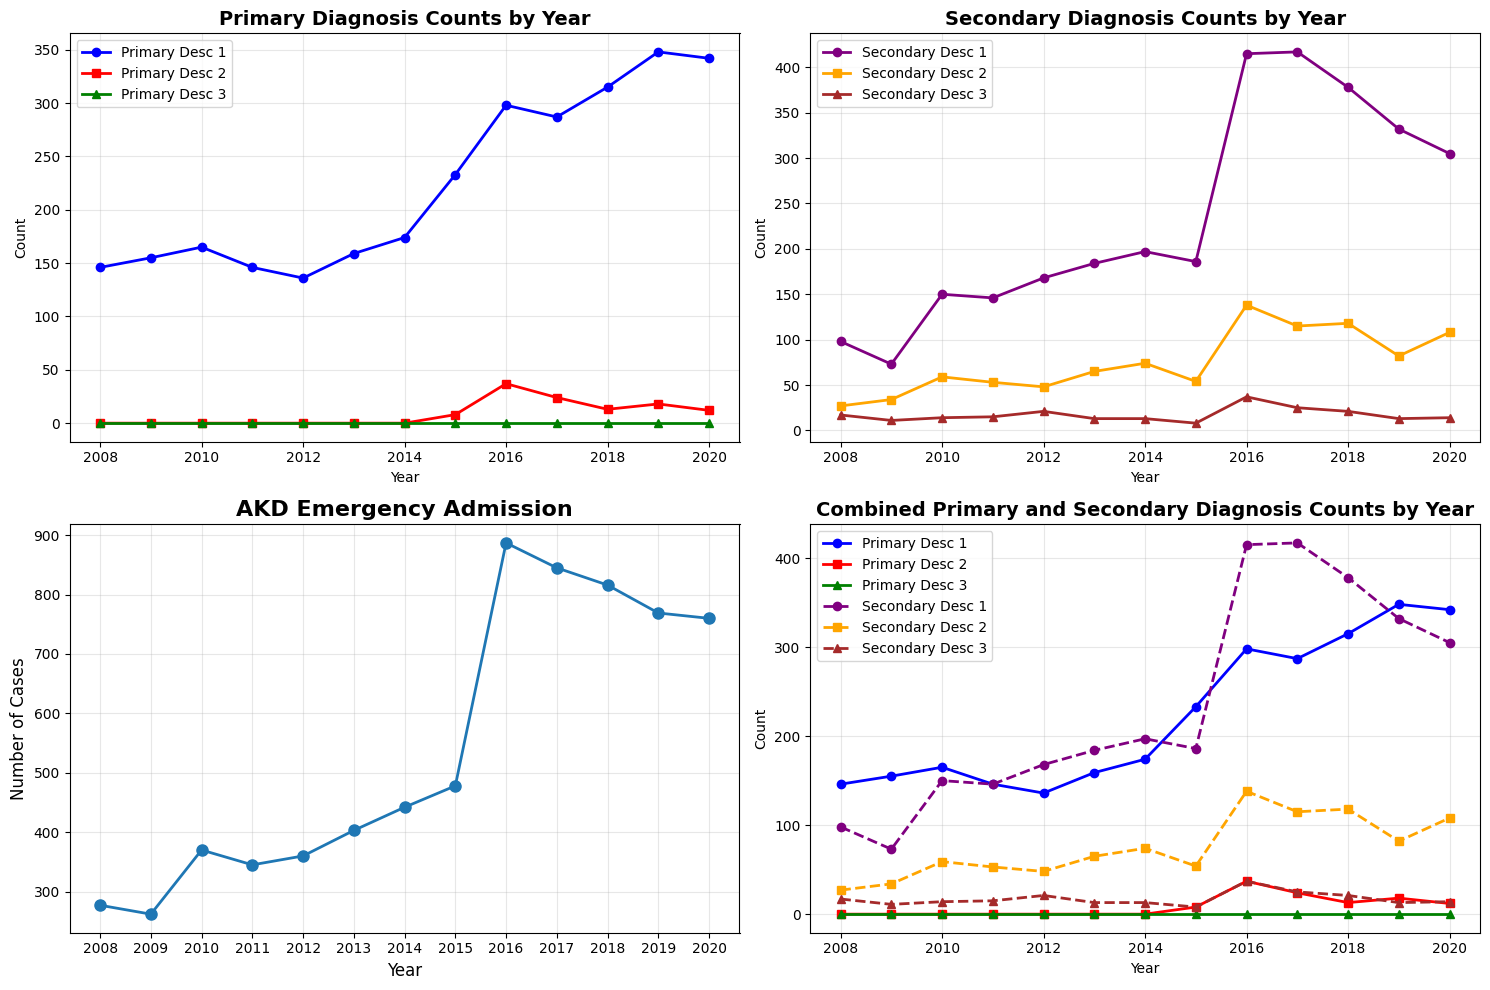

,year,primary_description_1_count,primary_description_2_count,primary_description_3_count,secondary_description_1_count,secondary_description_2_count,secondary_description_3_count,total_cases_year
0,2008,146,0,0,98,27,17,277
1,2009,155,0,0,73,34,11,262
2,2010,165,0,0,150,59,14,370
3,2011,146,0,0,146,53,15,345
4,2012,136,0,0,168,48,21,360
5,2013,159,0,0,184,65,13,403
6,2014,174,0,0,197,74,13,442
7,2015,233,8,0,186,54,8,478
8,2016,298,37,0,415,138,37,887
9,2017,287,24,0,417,115,25,845


In [35]:
# Plot the yearly_specific_df data
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Primary diagnosis counts by year
axes[0, 0].plot(yearly_specific_df['year'], yearly_specific_df['primary_description_1_count'], 
                marker='o', linewidth=2, markersize=6, label='Primary Desc 1', color='blue')
axes[0, 0].plot(yearly_specific_df['year'], yearly_specific_df['primary_description_2_count'], 
                marker='s', linewidth=2, markersize=6, label='Primary Desc 2', color='red')
axes[0, 0].plot(yearly_specific_df['year'], yearly_specific_df['primary_description_3_count'], 
                marker='^', linewidth=2, markersize=6, label='Primary Desc 3', color='green')
axes[0, 0].set_title('Primary Diagnosis Counts by Year', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Secondary diagnosis counts by year
axes[0, 1].plot(yearly_specific_df['year'], yearly_specific_df['secondary_description_1_count'], 
                marker='o', linewidth=2, markersize=6, label='Secondary Desc 1', color='purple')
axes[0, 1].plot(yearly_specific_df['year'], yearly_specific_df['secondary_description_2_count'], 
                marker='s', linewidth=2, markersize=6, label='Secondary Desc 2', color='orange')
axes[0, 1].plot(yearly_specific_df['year'], yearly_specific_df['secondary_description_3_count'], 
                marker='^', linewidth=2, markersize=6, label='Secondary Desc 3', color='brown')
axes[0, 1].set_title('Secondary Diagnosis Counts by Year', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Create a plot showing AKD admissions by year
axes[1, 0].plot(acute_kidney_renal_by_year.index, acute_kidney_renal_by_year.values, marker='o', linewidth=2, markersize=8)
axes[1, 0].set_title('AKD Emergency Admission', fontsize=16, fontweight='bold')
axes[1, 0].set_xlabel('Year', fontsize=12)
axes[1, 0].set_ylabel('Number of Cases', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(acute_kidney_renal_by_year.index)

# Plot 4: Combined Primary and Secondary Diagnosis Counts by Year
axes[1, 1].plot(yearly_specific_df['year'], yearly_specific_df['primary_description_1_count'], 
                marker='o', linewidth=2, markersize=6, label='Primary Desc 1', color='blue')
axes[1, 1].plot(yearly_specific_df['year'], yearly_specific_df['primary_description_2_count'], 
                marker='s', linewidth=2, markersize=6, label='Primary Desc 2', color='red')
axes[1, 1].plot(yearly_specific_df['year'], yearly_specific_df['primary_description_3_count'], 
                marker='^', linewidth=2, markersize=6, label='Primary Desc 3', color='green')
axes[1, 1].plot(yearly_specific_df['year'], yearly_specific_df['secondary_description_1_count'], 
                marker='o', linewidth=2, markersize=6, label='Secondary Desc 1', color='purple', linestyle='--')
axes[1, 1].plot(yearly_specific_df['year'], yearly_specific_df['secondary_description_2_count'], 
                marker='s', linewidth=2, markersize=6, label='Secondary Desc 2', color='orange', linestyle='--')
axes[1, 1].plot(yearly_specific_df['year'], yearly_specific_df['secondary_description_3_count'], 
                marker='^', linewidth=2, markersize=6, label='Secondary Desc 3', color='brown', linestyle='--')
axes[1, 1].set_title('Combined Primary and Secondary Diagnosis Counts by Year', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display the dataframe
yearly_specific_df

In [ ]:
# Add comments explaining the upper right plot (secondary diagnosis counts)
This plot shows the trend of acute kidney failure/injury cases when it appears as a secondary diagnosis
Secondary diagnosis means AKD was not the primary reason for emergency admission, but was present
as a comorbidity or developed during the hospital stay
# The three lines represent:
# - Secondary Desc 1: First secondary diagnosis position
# - Secondary Desc 2: Second secondary diagnosis position  
# - Secondary Desc 3: Third secondary diagnosis position
# This helps identify cases where patients were admitted for other conditions but also had AKD


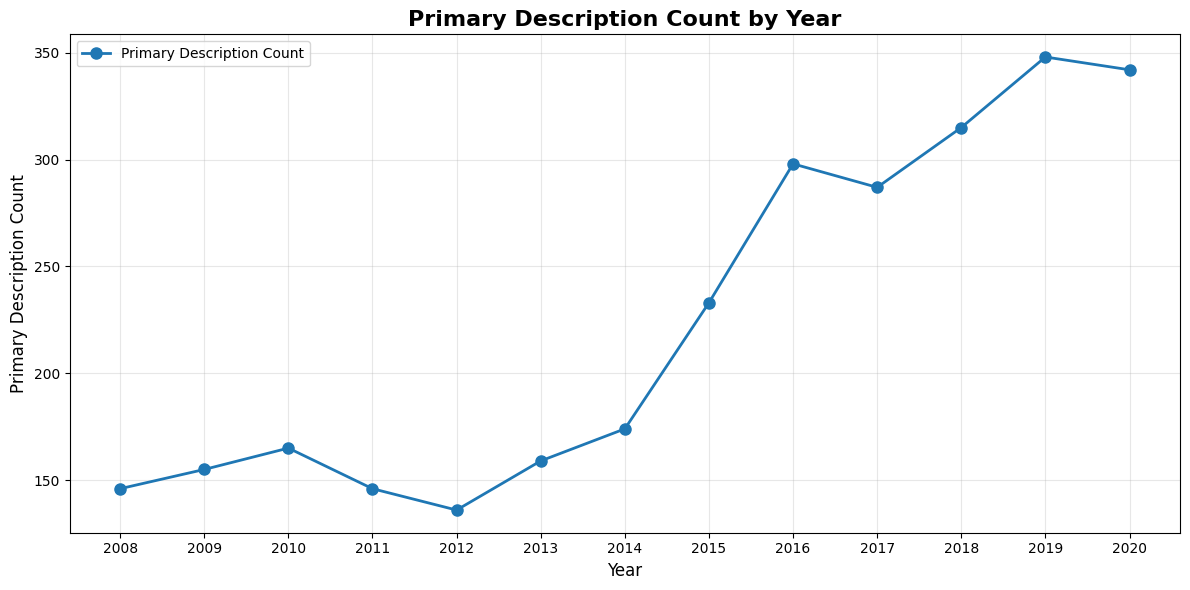

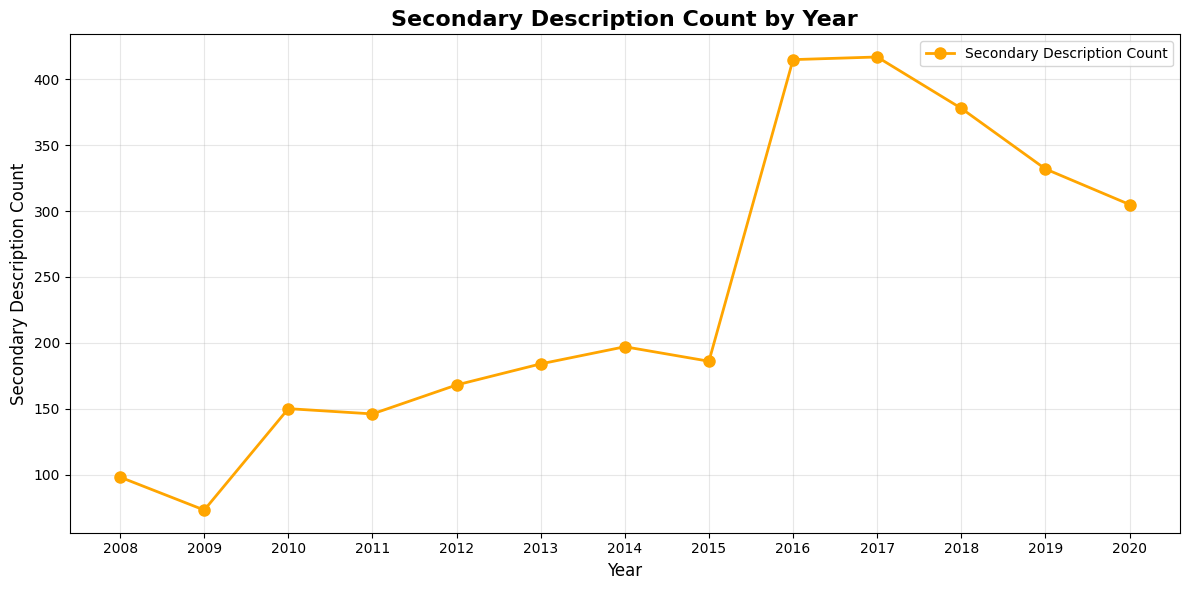

In [30]:
# Display the yearly_specific_df
yearly_specific_df

# Plot years vs primary_description_count
plt.figure(figsize=(12, 6))
plt.plot(yearly_specific_df['year'], yearly_specific_df['primary_description_count'], marker='o', linewidth=2, markersize=8, label='Primary Description Count')
plt.title('Primary Description Count by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Primary Description Count', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(yearly_specific_df['year'])
plt.legend()
plt.tight_layout()
plt.show()

# Plot years vs secondary_description_count
plt.figure(figsize=(12, 6))
plt.plot(yearly_specific_df['year'], yearly_specific_df['secondary_description_count'], marker='o', linewidth=2, markersize=8, label='Secondary Description Count', color='orange')
plt.title('Secondary Description Count by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Secondary Description Count', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(yearly_specific_df['year'])
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
yearly_specific_df

,year,primary_description_1_count,primary_description_2_count,primary_description_3_count,secondary_description_1_count,secondary_description_2_count,secondary_description_3_count,total_cases_year
0,2008,146,0,0,98,27,17,277
1,2009,155,0,0,73,34,11,262
2,2010,165,0,0,150,59,14,370
3,2011,146,0,0,146,53,15,345
4,2012,136,0,0,168,48,21,360
5,2013,159,0,0,184,65,13,403
6,2014,174,0,0,197,74,13,442
7,2015,233,8,0,186,54,8,478
8,2016,298,37,0,415,138,37,887
9,2017,287,24,0,417,115,25,845


In [ ]:
# Group acute kidney/renal cases by year
acute_kidney_renal_by_year = acute_kidney_renal_df.groupby('year').size()
print("Acute kidney/renal cases by year:")
print(acute_kidney_renal_by_year)

# Show the dataframe grouped by year
print("\nDetailed breakdown by year:")
for year in sorted(acute_kidney_renal_df['year'].unique()):
    year_data = acute_kidney_renal_df[acute_kidney_renal_df['year'] == year]
    print(f"\nYear {year}: {len(year_data)} cases")
    print(year_data.head())



Acute kidney/renal cases by year:
year
2008    277
2009    262
2010    370
2011    345
2012    360
2013    403
2014    442
2015    478
2016    887
2017    845
2018    816
2019    769
2020    760
dtype: int64

Detailed breakdown by year:

Year 2008: 277 cases
      DIAGNOSIS_CODE_Primary_1  DIAGNOSIS_CODE_Primary_2  \
2469                       584                       NaN   
7706                       584                       NaN   
9281                       584                       NaN   
20766                      560                       NaN   
36000                      584                       NaN   

                         DIAGNOSIS_DESCRIPTION_Primary_1  \
2469         Acute Renal Failure from severe dehydration   
7706                                 Acute Renal Failure   
9281                                 Acute Renal Failure   
20766                             Intestinal Obstruction   
36000  Acute Renal Failure secondary to ?obstructive ...   

      DIAGNOSIS_DES

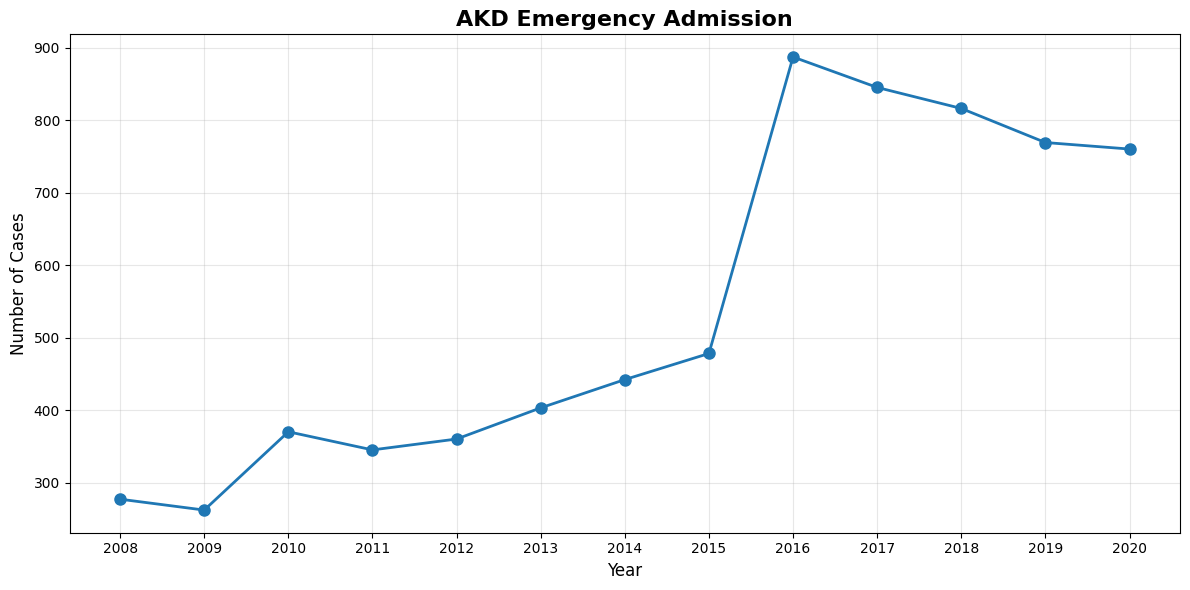

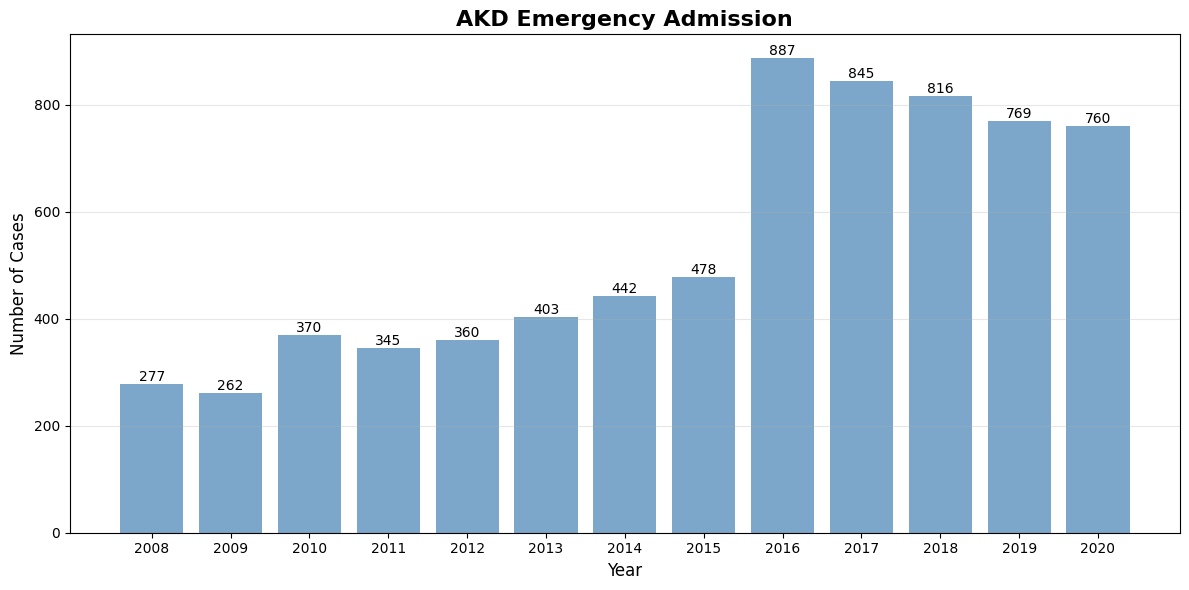

In [24]:

# Create a plot showing AKD admissions by year
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(acute_kidney_renal_by_year.index, acute_kidney_renal_by_year.values, marker='o', linewidth=2, markersize=8)
plt.title('AKD Emergency Admission', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(acute_kidney_renal_by_year.index)
plt.tight_layout()
plt.show()

# Also create a bar plot for better visualization
plt.figure(figsize=(12, 6))
bars = plt.bar(acute_kidney_renal_by_year.index, acute_kidney_renal_by_year.values, alpha=0.7, color='steelblue')
plt.title('AKD Emergency Admission', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(acute_kidney_renal_by_year.index)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [14]:
# Search for 'kidney' keyword in the emergency dataset
kidney_columns = [col for col in emergency_df.columns if 'kidney' in col.lower()]
print("Columns containing 'kidney':")
print(kidney_columns)

# Search for 'kidney' in diagnosis codes and descriptions
diagnosis_cols = [col for col in emergency_df.columns if 'DIAGNOSIS' in col.upper()]
print("\nDiagnosis columns:")
print(diagnosis_cols)

# Look for kidney-related entries in diagnosis descriptions
if diagnosis_cols:
    for col in diagnosis_cols:
        if emergency_df[col].dtype == 'object':
            kidney_entries = emergency_df[emergency_df[col].str.contains('kidney', case=False, na=False)]
            if len(kidney_entries) > 0:
                print(f"\nFound {len(kidney_entries)} entries with 'kidney' in {col}:")
                print(kidney_entries[col].value_counts())

emergency_df

Columns containing 'kidney':
[]

Diagnosis columns:
['DIAGNOSIS_CODE_Primary_1', 'DIAGNOSIS_CODE_Primary_2', 'DIAGNOSIS_DESCRIPTION_Primary_1', 'DIAGNOSIS_DESCRIPTION_Primary_2', 'DIAGNOSIS_CODE_Secondary_1', 'DIAGNOSIS_CODE_Secondary_2', 'DIAGNOSIS_CODE_Secondary_3', 'DIAGNOSIS_DESCRIPTION_Secondary_1', 'DIAGNOSIS_DESCRIPTION_Secondary_2', 'DIAGNOSIS_DESCRIPTION_Secondary_3']

Found 3613 entries with 'kidney' in DIAGNOSIS_DESCRIPTION_Primary_1:
DIAGNOSIS_DESCRIPTION_Primary_1
AKI - Acute kidney injury                                                      1367
Calculus Of Kidney And Ureter                                                   744
CKD - chronic kidney disease                                                    216
Chronic kidney disease                                                          160
Calculus Of Kidney                                                              123
                                                                               ... 
Carcinoma Of K

,Unnamed: 0,AE_CASE_NUMBER,#PATIENT_CODE,AGE,DEATH_DATE,DEATH_REASON,GENDER,NATIONALITY,POSTAL_CODE,RACE,...,DIAGNOSIS_CODE_Primary_2,DIAGNOSIS_DESCRIPTION_Primary_1,DIAGNOSIS_DESCRIPTION_Primary_2,DIAGNOSIS_CODE_Secondary_1,DIAGNOSIS_CODE_Secondary_2,DIAGNOSIS_CODE_Secondary_3,DIAGNOSIS_DESCRIPTION_Secondary_1,DIAGNOSIS_DESCRIPTION_Secondary_2,DIAGNOSIS_DESCRIPTION_Secondary_3,year
0,1,00000C60C4122D134829896AF2EE33A7,A62401314B262C6576B454AC6A28235E,30.0,NaN,NaN,MALE,Singapore Citizen,4600.0,Chinese,...,NaN,Cellulitis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018
1,2,00000CCC36795BC7D604069B032DE81D,B6D4474C33CCFBE88B1E6AFA14AB1CBD,53.0,NaN,NaN,FEMALE,Singapore Citizen,5702.0,Chinese,...,NaN,Acute Loss of Short Term Memory,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008
2,3,00000F784DDDDB38D43C26018702EA4A,8613CC9F0A3523FF969E3C15DBF147F2,66.0,NaN,NaN,FEMALE,Singapore Citizen,3300.0,Chinese,...,NaN,Cellulitis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014
3,4,0000156D5B4BC06B11C4983753A2C187,B6EB1F8034184B9D7FB6FB180BCE6D38,51.0,NaN,NaN,MALE,Singapore Citizen,6803.0,Chinese,...,NaN,Viral fever,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020
4,5,00001B3D4DD023D6566EC69B148F4666,7F532DD03EC1865BB51D83855EBE57C4,24.0,NaN,NaN,FEMALE,Thai,1896.0,Thai,...,NaN,musculoskeletal pain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1833903,1833904,FFFFE391F72DFAD9F0D1888D3664AA7F,327D972977EB206736838E296DE873A9,53.0,2008-09-06,NaN,MALE,Singapore Citizen,5401,Chinese,...,NaN,Nausea And Vomiting likely from uraemia,NaN,5119.0,NaN,NaN,Unspecified Pleural Effusion,NaN,NaN,2008
1833904,1833905,FFFFE5B6C54AA2F69619548D979D5EB9,43187936BDC8F529709B7A9C350EA59C,60.0,NaN,NaN,MALE,Singapore Citizen,1601,Other Races,...,72303014.0,Upper GI bleeding,Hypokalemia,350049016.0,62348012.0,2920634011.0,Pneumonia,Upper GI bleeding,Acute renal failure,2017
1833905,1833906,FFFFF739EF804B9678F617D68A7BFB70,B79B647EC1A3AB2563A8982AED61D71F,28.0,NaN,NaN,MALE,Indonesian,NaN,Indonesian,...,NaN,Contusion Of Face Scalp And Neck,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009
1833906,1833907,FFFFF8ABC858201A73BB14CB23BB48AA,1D60FAC35997ED2969EB5262BFF08FB6,14.0,NaN,NaN,MALE,Singapore Citizen,5502,Chinese,...,NaN,Minor Head Injury,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010


In [12]:
# Search for 'renal' keyword in the emergency dataset
renal_columns = [col for col in emergency_df.columns if 'renal' in col.lower()]
print("Columns containing 'renal':")
print(renal_columns)

# Search for 'renal' in diagnosis codes and descriptions
diagnosis_cols = [col for col in emergency_df.columns if 'DIAGNOSIS' in col.upper()]
print("\nDiagnosis columns:")
print(diagnosis_cols)

# Look for renal-related entries in diagnosis descriptions
if diagnosis_cols:
    for col in diagnosis_cols:
        if emergency_df[col].dtype == 'object':
            renal_entries = emergency_df[emergency_df[col].str.contains('renal', case=False, na=False)]
            if len(renal_entries) > 0:
                print(f"\nFound {len(renal_entries)} entries with 'renal' in {col}:")
                print(renal_entries[col].value_counts().head())

emergency_df

Columns containing 'renal':
['Renal']

Diagnosis columns:
['DIAGNOSIS_CODE_Primary_1', 'DIAGNOSIS_CODE_Primary_2', 'DIAGNOSIS_DESCRIPTION_Primary_1', 'DIAGNOSIS_DESCRIPTION_Primary_2', 'DIAGNOSIS_CODE_Secondary_1', 'DIAGNOSIS_CODE_Secondary_2', 'DIAGNOSIS_CODE_Secondary_3', 'DIAGNOSIS_DESCRIPTION_Secondary_1', 'DIAGNOSIS_DESCRIPTION_Secondary_2', 'DIAGNOSIS_DESCRIPTION_Secondary_3']

Found 29517 entries with 'renal' in DIAGNOSIS_DESCRIPTION_Primary_1:
DIAGNOSIS_DESCRIPTION_Primary_1
Renal Colic                       8078
Renal colic                       5315
End Stage Renal Failure           2884
ESRF - End stage renal failure    2260
Chronic Renal Failure              919
Name: count, dtype: int64

Found 238 entries with 'renal' in DIAGNOSIS_DESCRIPTION_Primary_2:
DIAGNOSIS_DESCRIPTION_Primary_2
Renal colic                       119
ESRF - End stage renal failure     28
Acute-on-chronic renal failure     21
Acute renal failure                16
Renal stone                         9
N

,Unnamed: 0,AE_CASE_NUMBER,#PATIENT_CODE,AGE,DEATH_DATE,DEATH_REASON,GENDER,NATIONALITY,POSTAL_CODE,RACE,...,DIAGNOSIS_CODE_Primary_2,DIAGNOSIS_DESCRIPTION_Primary_1,DIAGNOSIS_DESCRIPTION_Primary_2,DIAGNOSIS_CODE_Secondary_1,DIAGNOSIS_CODE_Secondary_2,DIAGNOSIS_CODE_Secondary_3,DIAGNOSIS_DESCRIPTION_Secondary_1,DIAGNOSIS_DESCRIPTION_Secondary_2,DIAGNOSIS_DESCRIPTION_Secondary_3,year
0,1,00000C60C4122D134829896AF2EE33A7,A62401314B262C6576B454AC6A28235E,30.0,NaN,NaN,MALE,Singapore Citizen,4600.0,Chinese,...,NaN,Cellulitis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018
1,2,00000CCC36795BC7D604069B032DE81D,B6D4474C33CCFBE88B1E6AFA14AB1CBD,53.0,NaN,NaN,FEMALE,Singapore Citizen,5702.0,Chinese,...,NaN,Acute Loss of Short Term Memory,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008
2,3,00000F784DDDDB38D43C26018702EA4A,8613CC9F0A3523FF969E3C15DBF147F2,66.0,NaN,NaN,FEMALE,Singapore Citizen,3300.0,Chinese,...,NaN,Cellulitis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014
3,4,0000156D5B4BC06B11C4983753A2C187,B6EB1F8034184B9D7FB6FB180BCE6D38,51.0,NaN,NaN,MALE,Singapore Citizen,6803.0,Chinese,...,NaN,Viral fever,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020
4,5,00001B3D4DD023D6566EC69B148F4666,7F532DD03EC1865BB51D83855EBE57C4,24.0,NaN,NaN,FEMALE,Thai,1896.0,Thai,...,NaN,musculoskeletal pain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1833903,1833904,FFFFE391F72DFAD9F0D1888D3664AA7F,327D972977EB206736838E296DE873A9,53.0,2008-09-06,NaN,MALE,Singapore Citizen,5401,Chinese,...,NaN,Nausea And Vomiting likely from uraemia,NaN,5119.0,NaN,NaN,Unspecified Pleural Effusion,NaN,NaN,2008
1833904,1833905,FFFFE5B6C54AA2F69619548D979D5EB9,43187936BDC8F529709B7A9C350EA59C,60.0,NaN,NaN,MALE,Singapore Citizen,1601,Other Races,...,72303014.0,Upper GI bleeding,Hypokalemia,350049016.0,62348012.0,2920634011.0,Pneumonia,Upper GI bleeding,Acute renal failure,2017
1833905,1833906,FFFFF739EF804B9678F617D68A7BFB70,B79B647EC1A3AB2563A8982AED61D71F,28.0,NaN,NaN,MALE,Indonesian,NaN,Indonesian,...,NaN,Contusion Of Face Scalp And Neck,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009
1833906,1833907,FFFFF8ABC858201A73BB14CB23BB48AA,1D60FAC35997ED2969EB5262BFF08FB6,14.0,NaN,NaN,MALE,Singapore Citizen,5502,Chinese,...,NaN,Minor Head Injury,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010


In [11]:
emergency_df.columns

Index(['Unnamed: 0', 'AE_CASE_NUMBER', '#PATIENT_CODE', 'AGE', 'DEATH_DATE',
       'DEATH_REASON', 'GENDER', 'NATIONALITY', 'POSTAL_CODE', 'RACE',
       ...
       'DIAGNOSIS_CODE_Primary_2', 'DIAGNOSIS_DESCRIPTION_Primary_1',
       'DIAGNOSIS_DESCRIPTION_Primary_2', 'DIAGNOSIS_CODE_Secondary_1',
       'DIAGNOSIS_CODE_Secondary_2', 'DIAGNOSIS_CODE_Secondary_3',
       'DIAGNOSIS_DESCRIPTION_Secondary_1',
       'DIAGNOSIS_DESCRIPTION_Secondary_2',
       'DIAGNOSIS_DESCRIPTION_Secondary_3', 'year'],
      dtype='object', length=139)